<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Coulomb_matrix_representation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Mount you G-drive so all the files are in one place

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
#Load modules and data

! pip install dscribe
import numpy as np
import math, random
import matplotlib.pyplot as plt
import pandas as pd
import json
import seaborn as sns
from scipy.sparse import load_npz
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from dscribe.descriptors import CoulombMatrix 
from ase import *
from ase.build import molecule
from ase.io import read, write
import io


In [6]:
!cp '/content/drive/MyDrive/ColabNotebooks/Data/helpers.py' .

from helpers import get_level  # needs to go here as wont have been downloaded earlier in

def xyz_to_atoms(xyz):
    f = io.StringIO()
    f.write(xyz)
    f.seek(0)  # had to add this in otherwise wont return to start of file once read in
    atoms = read(f, format="xyz")
    return atoms

print('Loading data...')
df = pd.read_json('/content/drive/MyDrive/ColabNotebooks/Data/df_5k.json', orient='split')

print('Generating `ase.Atoms` objects...')
df['atoms'] = df['xyz_pbe_relaxed'].apply(xyz_to_atoms)

print('Extracting HOMO, LUMO, BANDGAP from data...')
df['HOMO'] = df.apply(lambda row: get_level(row, level_type='HOMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['LUMO'] = df.apply(lambda row: get_level(row, level_type='LUMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['BG'] = df['LUMO'] - df['HOMO']
print('~ 2300 molecules do not have LUMO energy levels for this or any other `GOWO` level of theory.')

# print('Splitting data set...')
# train, test = train_test_split(df, test_size=0.2, random_state=20210817)
# train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

print('Data Processing Complete')
print('#', '-'*119)

Loading data...
Generating `ase.Atoms` objects...
Extracting HOMO, LUMO, BANDGAP from data...
err FOVWES
err FOWGIH
err FOYJUZ
err FUNBUL
err FUPZAR
err FUXFAG
err GANSAQ
err GAQCEI
err NUFRUB
err GEPHEO
err GERGOB
err GETBUD
err GEVDAN
err GEYQAC
err GIDQAN
err GIMPUO
err GISBOA
err NUNJAH
err NUNJEL
err NUNKEM
err GODBUW
err NUQCIM
err WEBWUV
err GUCLIA
err GUMBEV
err HACGAT
err HADSEM
err HANBEF
err HANNEP
err LUXPAW
err HAVSIH
err HAWTEF
err HAXWAG
err HAZFNO
err HEHQIW
err HEJGOS
err HELCEG
err HEMLIU
err HEQMOG
err HERKEV
err HESKOF01
err HEVNAX
err HEVNIF
err HEWJIE
err OBOYOV
err HIFYAY
err HIJCEI
err HINREB
err HINTAZ
err WUJHOY
err HIVCOF
err HIXLOP
err WULZIM
err HMNCXC01
err HMSPYR
err HMTCSP10
err HOFJOB
err HOHGER
err HOHLAR
err HOJVUX
err HOKZEN
err HOQHUQ
err HORNUY
err OCAYUN
err HUHJUQ
err HUXKOB
err IFEFII
err IFOQIE
err LUZKEX
err IJEDAC
err IJENIU
err IJIWIH
err ILIGAM
err ILOCAN
err LOFBUD
err XILQUE
err IMINEY
err IMSTXP10
err IQAHUD
err XINWUN
err IROQOV
err IRU

Inspect the dataframe 

In [7]:
col_names = list(df.columns)
print(col_names)
df.head(3)
print(df.shape)

['refcode_csd', 'canonical_smiles', 'inchi', 'number_of_atoms', 'xyz_pbe_relaxed', 'energies_occ_pbe', 'energies_occ_pbe0_vac_tier2', 'energies_occ_pbe0_water', 'energies_occ_pbe0_vac_tzvp', 'energies_occ_pbe0_vac_qzvp', 'energies_occ_gw_tzvp', 'energies_occ_gw_qzvp', 'cbs_occ_gw', 'energies_unocc_pbe', 'energies_unocc_pbe0_vac_tier2', 'energies_unocc_pbe0_water', 'energies_unocc_pbe0_vac_tzvp', 'energies_unocc_pbe0_vac_qzvp', 'energies_unocc_gw_tzvp', 'energies_unocc_gw_qzvp', 'cbs_unocc_gw', 'total_energy_pbe', 'total_energy_pbe0_vac_tier2', 'total_energy_pbe0_water', 'total_energy_pbe0_vac_tzvp', 'total_energy_pbe0_vac_qzvp', 'hirshfeld_pbe', 'hirshfeld_pbe0_vac_tier2', 'hirshfeld_pbe0_water', 'atoms', 'HOMO', 'LUMO', 'BG']
(5239, 33)


Begin with looking at just one example at random from the dataframe

In [5]:

#Lets look at a random molecule represented with a Coulomb matrix 
y = df['xyz_pbe_relaxed'].shape[0]
# print(df['xyz_pbe_relaxed'])
print(y)

rand_mol = random.randint(0, y)
print(df['xyz_pbe_relaxed'].iloc[rand_mol])
mol_of_choice = df['xyz_pbe_relaxed'].iloc[rand_mol]


5239
26

C 23.46184557 26.34213640 21.83656173 
C 24.14038740 24.75757578 19.62058426 
C 22.17599922 23.30379205 20.06361232 
C 21.06394433 22.99554307 20.82244081 
C 20.72230094 23.79266700 21.93623724 
C 21.49862480 24.88435600 22.27250131 
C 22.64477664 25.22488171 21.51328581 
C 22.99083321 24.41705324 20.38400219 
H 24.39378469 24.13610265 18.76348643 
H 22.44132436 22.68838591 19.20216820 
H 20.44751669 22.13514701 20.56218727 
H 19.84335426 23.54450981 22.53111207 
H 21.23562337 25.50144756 23.13343805 
C 24.57324856 26.65666559 21.08471444 
H 23.18909261 26.94941847 22.69787164 
H 24.13924002 29.02669481 22.31660728 
H 27.33193433 25.97153264 17.76218313 
H 25.65044353 25.49120276 17.36777349 
O 26.03572021 26.24985896 19.28153891 
C 24.92064162 25.84505470 19.94913091 
C 26.42947879 25.48669040 18.14698499 
H 26.66206378 24.44541342 18.42227699 
O 25.41457127 27.70185584 21.31422603 
C 25.12296409 28.54222041 22.42477311 
H 25.90614613 29.30650584 22.43195517 
H 25.14951805 27

Visually present the random molecule of choice in the CM representation

(26, 26)


<Figure size 432x288 with 0 Axes>

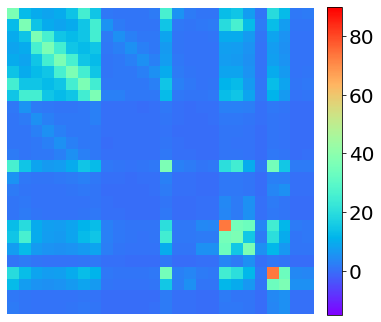

In [11]:
cm_desc = CoulombMatrix(n_atoms_max=26, permutation='none', flatten=False)
mol = df['atoms'].iloc[rand_mol]

matrix = cm_desc.create(mol)
print(matrix.shape)

#Lets have a look at our random molecule and visualise the CM
plt.figure()
plt.figure(figsize = (6,6))
plt.imshow(matrix, origin="upper", cmap='rainbow', vmin=-15, vmax=90, interpolation='nearest')
plt.colorbar(fraction=0.046, pad=0.04).ax.tick_params(labelsize=20)
plt.axis('off')
plt.show()

Last inspection of the data frame is to look at the distribution of our labels - in this case these are the HOMO values

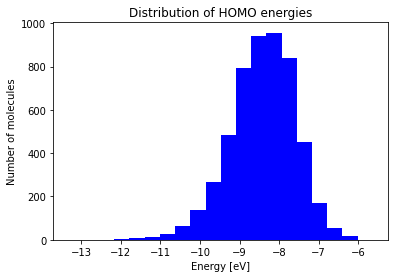

Mean value of HOMO energies in OE62 dataset: -8.42 eV


In [12]:
plt.hist(df['HOMO'].values, bins=20, density=False, facecolor='blue')
plt.xlabel("Energy [eV]")
plt.ylabel("Number of molecules")
plt.title("Distribution of HOMO energies")
plt.show()

## mean value of distribution
print("Mean value of HOMO energies in OE62 dataset: %0.2f eV" %np.mean(df['HOMO'].values))

Perform the split of data

In [13]:
 train, test = train_test_split(df, test_size=0.2, random_state=20210817)
train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

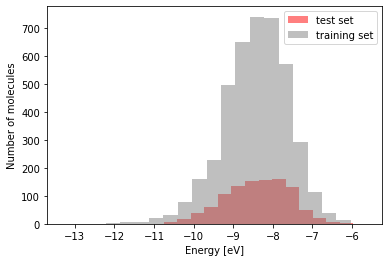

Mean value of HOMO energies in training set: -8.43 eV
Mean value of HOMO energies in test set: -8.39 eV


In [14]:
#Lets visualise the data for each split to see if it resembles each other


plt.hist(test['HOMO'].values, bins=20, density=False, alpha=0.5, facecolor='red', label='test set')
plt.hist(train['HOMO'].values, bins=20, density=False, alpha=0.5, facecolor='gray', label='training set')
plt.xlabel("Energy [eV]")
plt.ylabel("Number of molecules")
plt.legend()
plt.show()

## mean value of distributions
print("Mean value of HOMO energies in training set: %0.2f eV" %np.mean(train['HOMO'].values))
print("Mean value of HOMO energies in test set: %0.2f eV" %np.mean(test['HOMO'].values))

This is a simple model which works

In [29]:
atomic_numbers = df['atoms'].apply(lambda x: x.numbers)
unique_atomic_numbers = set([a for b in atomic_numbers for a in b])
max_num_atoms = atomic_numbers.apply(len).max()

print(unique_atomic_numbers)
print(max_num_atoms)

feature_calc = CoulombMatrix(n_atoms_max=max_num_atoms)
print('Generating features...')
X_train, X_test = (np.vstack([feature_calc.create(a) for a in d]) for d in (train_atoms, test_atoms))
print('Features generated.')


y_train = train['HOMO'].values  # extract target value from dataframe
y_test = test['HOMO'].values
y_ave = np.average(y_train)

#normalise data
y_train_tf = (y_train-y_ave)/y_ave
y_test_tf = (y_test-y_ave)/y_ave


# split the training data again intor training and cross validation sets
X_tr, X_cv, y_tr, y_cv = train_test_split(X_train, y_train_tf, test_size=0.2, random_state=1)

model = KernelRidge(kernel='rbf', alpha=0.01, gamma=0.01) 
model.fit(X_tr, y_tr)

y_pred_tr = model.predict(X_tr)
y_pred_cv = model.predict(X_cv)
y_pred_ts = model.predict(X_test)

y_pred_tr = (y_pred_tr * y_ave)+y_ave
y_pred_cv = (y_pred_cv * y_ave)+y_ave
y_pred_ts = (y_pred_ts * y_ave)+y_ave


for s, pred, ref in zip(('train', 'cv', 'test'), (y_pred_tr, y_pred_cv, y_pred_ts), (y_tr, y_cv,y_test)):
  mse = mean_squared_error(ref, pred)
  r2 = r2_score(ref, pred)

  print(F'{s} : mse={mse:.3f}, r2={r2:.3f}')



{1, 34, 35, 33, 5, 6, 7, 8, 9, 3, 14, 15, 16, 17, 53}
100
Generating features...
Features generated.
train : mse=72.009, r2=-7431.754
cv : mse=71.005, r2=-7851.799
test : mse=0.671, r2=-0.002


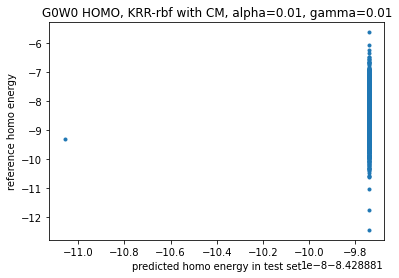

In [30]:
plt.plot(y_pred_ts, y_test,lw=0.0,marker='.')
#plt.ylim(-13,-6)
#plt.xlim(-13,-6)
plt.xlabel('predicted homo energy in test set')
plt.ylabel('reference homo energy')
plt.title('G0W0 HOMO, KRR-rbf with CM, alpha=0.01, gamma=0.01')
plt.show()

In [ ]:
# set up grids for alpha and gamma hyperparameters. 
# first value: lower bound; second value: upper bound; 
# third value: number of points to evaluate (here set to '3' --> '-2', '-1' and '0' are evaluated)
# --> make sure to change third value as well when changing the bounds!
alpha = np.logspace(-5, -2, 4)
gamma = np.logspace(-5, -2, 4)


cv_number = 5 ## choose into how many parts training set is divided for cross-validation
kernel = 'laplacian' # select kernel function here ('rbf': Gaussian kernel, 'laplacian': Laplacian kernel)
scoring_function = 'neg_mean_absolute_error' # it is called "negative" because scikit-learn interprets
                                             # highest scoring value as best, but we want small errors

## define settings for grid search routine in scikit-learn with above defined grids as input

grid_search = GridSearchCV(KernelRidge(),  #machine learning method (KRR here)
                           [{'kernel':[kernel],'alpha': alpha, 'gamma': gamma}], 
                           cv = cv_number, 
                           scoring = scoring_function,
                           verbose=1000)  ## produces detailed output statements of grid search 
                                          # routine so we can see what is computed
    
# call the fit function in scikit-learn which fits the Coulomb matrices in the training set 
# to their corresponding HOMO energies.
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[CV] alpha=1e-05, gamma=1e-05, kernel=laplacian ......................
[CV]  alpha=1e-05, gamma=1e-05, kernel=laplacian, score=-0.471, total= 2.4min
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  2.4min remaining:    0.0s
[CV] alpha=1e-05, gamma=1e-05, kernel=laplacian ......................
[CV]  alpha=1e-05, gamma=1e-05, kernel=laplacian, score=-0.458, total= 2.4min
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:  4.8min remaining:    0.0s
[CV] alpha=1e-05, gamma=1e-05, kernel=laplacian ......................
[CV]  alpha=1e-05, gamma=1e-05, kernel=laplacian, score=-0.472, total= 2.4min
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  7.2min remaining:    0.0s
[CV] alpha=1e-05, gamma=1e-05, kernel=laplacian ......................
[CV]  alpha=1e-05, gamma=1e-05, kernel=laplacian, score=-0.469, total= 2.4min
[Parallel(n_jobs=1)]: 

Generate CM representation in the dataframe for all `atom objects`

In [19]:
cm_desc = CoulombMatrix(n_atoms_max=120, permutation='none', flatten=False)
# many_matrix = cm_desc.create(df['atoms'])
print(df.shape)
#Calum's victory 
df['CM_rep'] = df['atoms'].apply(cm_desc.create)
print("it worked")

train, test = train_test_split(df, test_size=0.2, random_state=20210817)
train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()
print(train.shape)
print(test.shape)

(5239, 33)
it worked
(4191, 34)
(1048, 34)


Varying hyper parameters

In [20]:
# set up grids for alpha and gamma hyperparameters. 
# first value: lower bound; second value: upper bound; 
# third value: number of points to evaluate (here set to '3' --> '-2', '-1' and '0' are evaluated)
# --> make sure to change third value as well when changing the bounds!
alpha = np.logspace(-5, -2, 4)
gamma = np.logspace(-5, -2, 4)

features = np.array(train["CM_rep"])
labels = np.array(train["HOMO"])

cv_number = 5 ## choose into how many parts training set is divided for cross-validation
kernel = 'laplacian' # select kernel function here ('rbf': Gaussian kernel, 'laplacian': Laplacian kernel)
scoring_function = 'neg_mean_absolute_error' # it is called "negative" because scikit-learn interprets
                                             # highest scoring value as best, but we want small errors

## define settings for grid search routine in scikit-learn with above defined grids as input

grid_search = GridSearchCV(KernelRidge(),  #machine learning method (KRR here)
                           [{'kernel':[kernel],'alpha': alpha, 'gamma': gamma}], 
                           cv = cv_number, 
                           scoring = scoring_function,
                           verbose=1000)  ## produces detailed output statements of grid search 
                                          # routine so we can see what is computed
    
# call the fit function in scikit-learn which fits the Coulomb matrices in the training set 
# to their corresponding HOMO energies.
grid_search.fit(features, labels)

In [21]:
means = grid_search.cv_results_['mean_test_score']
stds = grid_search.cv_results_['std_test_score']
for mean, std, params in zip(-means, stds, grid_search.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r" % (mean, std * 2, params))